# Data

In [1]:
import numpy as np
import pandas  as pd
import os
from IPython.display import clear_output
import pygad
from classes import MACDBacktester, backtest

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\data')
#os.getcwd()


STOCK = 'ETH'
FREQ = '4h'
level = 2

df = pd.read_csv(f'{STOCK}USD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\genetic')

price_column = 'close'
date_split = "2024-10-1"
tf = FREQ


timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)

working_dataset = df[tf]

working_dataset = working_dataset.iloc[-4050:,:]

train_end_index = int(len(working_dataset)*0.8)
TRAIN_END_DATE = working_dataset.index[train_end_index]

df_train = working_dataset.loc[:TRAIN_END_DATE]
df_train = df_train.drop(index=df_train.index[-1])


df_test = working_dataset.loc[TRAIN_END_DATE:,:]

assert len(df_train)+len(df_test)== len(working_dataset), "Some data are missed."


signal_price = 'smoothed_data'
real_price = 'close'

SEQ_LENGTH = 28

clear_output()


# Wavelet

In [2]:
os.getcwd()
os.chdir('..')

In [3]:
from denoise.dwt import *

In [4]:
df_train.loc[:,'smoothed_data'] = wavelet_denoising(df_train['close'], level=2)

In [5]:
df_test.loc[:,'smoothed_data'] = wavelet_denoising(df_test['close'], level=2)

C:\Users\arvin\AppData\Local\Temp\ipykernel_12352\800973465.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.loc[:,'smoothed_data'] = wavelet_denoising(df_test['close'], level=2)


# Test

## Backtester class

In [6]:
import numpy as np
import pandas as pd

class MACDBacktester:
    def __init__(self, data: pd.DataFrame, price: str = 'close', sell_fee: float = 0.115,
                 buy_fee: float = 0.115, initial_capital: float = 100):
        """
        It works as a trade analyzer with a specific amount of money and trading cost.
        
        :param data: DataFrame containing different features ('macd_line', 'signal_line', price = 'close', 'y_xlstm').
        :param price: For trading (default: 'close').
        :param sell_fee: Sell trading cost in percentage (default: 0.115).
        :param buy_fee: Buy trading cost in percentage (default: 0.115).
        :param initial_capital: Initial capital.
        """
        self.data = data.copy()
        self.real_price = price
        self.sell_fee_percent = sell_fee / 100
        self.buy_fee_percent = buy_fee / 100
        self.initial_capital = initial_capital
        self.trades = []
        self.data['positions'] = 0

    def generate_signals(self):
        """
        Generates trading signals based on the MACD-XLSTM strategy.
        """
        buy_signals = (self.data['macd_line'] > self.data['signal_line']) & \
                      (self.data['macd_line'].shift(1) <= self.data['signal_line'].shift(1)) #& \
                     # (self.data['y_xlstm'] > self.data['close'])
        sell_signals = (self.data['macd_line'] < self.data['signal_line']) & \
                       (self.data['macd_line'].shift(1) >= self.data['signal_line'].shift(1)) #& \
                     #  (self.data['y_xlstm'] < self.data['close'])
        
        raw_signals = np.zeros(len(self.data), dtype=np.int8)
        holding_position = False

        for i in range(len(self.data)):
            if buy_signals.iloc[i] and not holding_position:
                raw_signals[i] = 1
                holding_position = True
            elif sell_signals.iloc[i] and holding_position:
                raw_signals[i] = -1
                holding_position = False

        # Adjust the signals:
        # 1. If the first nonzero signal is a sell, remove it.
        trade_idx = np.where(raw_signals != 0)[0]
        if len(trade_idx) > 0 and raw_signals[trade_idx[0]] == -1:
            raw_signals[trade_idx[0]] = 0

        # 2. If the last signal is a buy, force a sell at the end.
        if len(trade_idx) > 0 and raw_signals[trade_idx[-1]] == 1:
            raw_signals[-1] = -1

        # Save the raw signals in a dedicated column.
        self.data['signals_macd_xlstm'] = raw_signals

        positions = np.zeros(len(self.data), dtype=np.int8)
        current_position = 0
        for i, signal in enumerate(raw_signals):
            if signal == 1:
                current_position = 1
            elif signal == -1:
                current_position = 0
            positions[i] = current_position
        self.data['positions'] = positions
        return self.data

    def backtest_strategy(self):
        """ Backtests the trading strategy. """
        self.data = self.data.copy()
        self.data['price'] = self.data[self.real_price]
        self.data['positions_diff'] = self.data['positions'].diff().fillna(0)
        
        self.data['cash'] = self.initial_capital
        self.data['holdings'] = 0.0
        self.data['total'] = self.initial_capital

        cash = self.initial_capital
        holdings = 0.0
        position = False
        buy_price = 0.0
        win_count = 0
        total_trades = 0

        for idx, row in self.data.iterrows():
            position_change = row['positions_diff']
            price = row['price']

            if position_change == 1 and not position:  # Enter long position
                holdings = cash * (1 - self.buy_fee_percent) / price
                cash = 0
                position = True
                buy_price = price

            elif position_change == -1 and position: # Exit long position
                cash = holdings * price * (1 - self.sell_fee_percent)
                holdings = 0
                position = False
                trade_return = ((price - buy_price) / buy_price) * 100
                self.trades.append(trade_return)
                total_trades += 1
                if trade_return > 0:
                    win_count += 1

            total = cash + (holdings * price if position else 0)
            self.data.at[idx, 'cash'] = float(cash)
            self.data.at[idx, 'holdings'] = float(holdings * price if position else 0)
            self.data.at[idx, 'total'] = float(total)

        self.results = self.data[['cash', 'holdings', 'total']]
        self.win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0
        return self.data, self.trades

    def get_performance_metrics(self):
        """
        Calculates and returns performance metrics.
        (Implementation remains unchanged.)
        """
        if not hasattr(self, 'results'):
            print("Please run backtest_strategy() before calculating performance metrics.")
            return None

        total_return = (self.results['total'].iloc[-1] - self.initial_capital) / self.initial_capital * 100
        returns = self.results['total'].pct_change().fillna(0)
        annualized_return = ((1 + returns.mean()) ** 365 - 1) * 100  # Assuming daily returns
        annualized_volatility = returns.std() * np.sqrt(365) * 100

        periods_per_year = 8760
        annual_rf_rate = 0.04  
        daily_rf_rate = annual_rf_rate / 365  
        hourly_rf_rate = daily_rf_rate / 24  

        excess_returns = returns - hourly_rf_rate
        mean_hourly_excess = excess_returns.mean()
        std_hourly = returns.std()  
        sharpe_ratio = (mean_hourly_excess / std_hourly) * np.sqrt(periods_per_year) if std_hourly != 0 else np.nan

        target_return = hourly_rf_rate  
        downside_returns = returns.copy()
        downside_returns[downside_returns > target_return] = 0
        std_downside = downside_returns.std()
        annualized_downside_deviation = std_downside * np.sqrt(periods_per_year)
        annualized_excess_return = mean_hourly_excess * periods_per_year
        sortino_ratio = annualized_excess_return / annualized_downside_deviation if annualized_downside_deviation != 0 else np.nan

        max_drawdown = ((self.results['total'].cummax() - self.results['total']) / self.results['total'].cummax()).max() * 100

        metrics = {
            'Total Return (%)': total_return,
            'Annualized Return (%)': annualized_return,
            'Annualized Volatility (%)': annualized_volatility,
            'Sharpe Ratio': sharpe_ratio,
            'Sortino Ratio': sortino_ratio,
            'Max Drawdown (%)': max_drawdown,
            'Win Rate (%)': self.win_rate
        }
        return metrics, self.results


    def print_trades(self):
        """ Prints individual trade returns. """
        if not self.trades:
            print("No trades have been executed.")
            return
        for idx, trade_return in enumerate(self.trades, 1):
            print(f"Trade {idx}: Return = {trade_return:.2f}%")
        total_return = np.sum(self.trades)
        print(f"Total Return from trades: {total_return:.2f}%")
        return self.trades



## run backterster

In [7]:
bestMacdCoeff = np.load(f'macdxlstm/28_{STOCK}_{FREQ}/best_macd_coefficients_close_{FREQ}.npy')

In [8]:
# df_all = np.vstack((df_train, df_test))
df_all = pd.concat([df_train, df_test], axis=0)

In [9]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length,:])
    return np.array(sequences, dtype=np.int64)


sequences = create_sequences(np.vstack((df_train,df_test)), seq_length=SEQ_LENGTH)

print(f'Created {len(sequences)} sequences of length {SEQ_LENGTH}.')

Created 4023 sequences of length 28.


In [10]:
def calculate_ema(values, period):
    return pd.Series(values).ewm(span=period, adjust=False).mean().values

def calculate_macd(sequence, fast_period, slow_period, signal_period):
    # calculate macd things for a sequence.
    macd_line = calculate_ema(sequence, fast_period)-calculate_ema(sequence, slow_period)
    signal_line = calculate_ema(macd_line, signal_period)
    histogram = macd_line-signal_line
    return macd_line, signal_line, histogram

In [11]:
macd_lines = []
signal_lines = []
histograms = []

In [12]:
for i, seq in enumerate(sequences):
    f,s,h = bestMacdCoeff[i]
    macd_line, signal_line, histogram = calculate_macd(seq[:,-1], fast_period=f,slow_period=s,signal_period=h)
    macd_lines.append(macd_line)
    signal_lines.append(signal_line)
    histograms.append(histogram)

macd_lines = np.array(macd_lines)
signal_lines = np.array(signal_lines)
histograms = np.array(histograms)

In [13]:
df_all[-4023:].shape

(4023, 6)

In [14]:
df_all = df_all[-4023:]
df_all.loc[:,'macd_line'] = macd_lines[:,-1]
df_all.loc[:,'signal_line'] = signal_lines[:,-1]
df_all.loc[:,'histo'] = histograms[:,-1]


In [15]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

In [16]:
df_all.to_csv(f'strategy/files/df_all_{STOCK}_{FREQ}.csv', index = False)

In [17]:
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
# backtester = MACDBacktester(df_test, best_params.get('Fast EMA'), best_params.get('Slow EMA'), best_params.get('Signal Line'),signal_price=signal_price, real_price=real_price)
backtester = MACDBacktester(df_all, price=real_price)
backtester.generate_signals()
backtester.backtest_strategy()
metrics, results = backtester.get_performance_metrics()
print(metrics)
backtester.print_trades()

C:\Users\arvin\AppData\Local\Temp\ipykernel_12352\3311999176.py:110: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.885' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'total'] = float(total)
C:\Users\arvin\AppData\Local\Temp\ipykernel_12352\3311999176.py:108: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.92849753928571' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  self.data.at[idx, 'cash'] = float(cash)


{'Total Return (%)': 10896.015504327648, 'Annualized Return (%)': 55.13240281645015, 'Annualized Volatility (%)': 15.958069822582937, 'Sharpe Ratio': 13.437179125367482, 'Sortino Ratio': 25.538772861474122, 'Max Drawdown (%)': 24.07634944467143, 'Win Rate (%)': 69.9738903394256}
Trade 1: Return = 0.16%
Trade 2: Return = 4.52%
Trade 3: Return = -0.30%
Trade 4: Return = 5.68%
Trade 5: Return = 7.40%
Trade 6: Return = -0.39%
Trade 7: Return = -0.94%
Trade 8: Return = -0.38%
Trade 9: Return = 7.80%
Trade 10: Return = -0.43%
Trade 11: Return = -0.24%
Trade 12: Return = -0.06%
Trade 13: Return = 3.89%
Trade 14: Return = 1.66%
Trade 15: Return = 5.16%
Trade 16: Return = 1.98%
Trade 17: Return = 6.17%
Trade 18: Return = 0.24%
Trade 19: Return = 0.84%
Trade 20: Return = 1.35%
Trade 21: Return = 3.01%
Trade 22: Return = -1.82%
Trade 23: Return = 3.66%
Trade 24: Return = 9.26%
Trade 25: Return = -0.35%
Trade 26: Return = -0.12%
Trade 27: Return = 1.37%
Trade 28: Return = 1.30%
Trade 29: Return = 

[0.15873015873015872,
 4.520222045995242,
 -0.3003003003003003,
 5.681818181818182,
 7.404795486600846,
 -0.3861003861003861,
 -0.9439899307740718,
 -0.37831021437578816,
 7.79816513761468,
 -0.428921568627451,
 -0.24449877750611246,
 -0.06476683937823835,
 3.8935756002595716,
 1.6634676903390915,
 5.159235668789809,
 1.9820971867007673,
 6.1704834605597965,
 0.24301336573511542,
 0.8438818565400843,
 1.354679802955665,
 3.0079803560466543,
 -1.8170019467878002,
 3.6593479707252166,
 9.25566343042071,
 -0.35252643948296125,
 -0.1182033096926714,
 1.3682331945270672,
 1.301921884686919,
 1.5047021943573669,
 -0.7936507936507936,
 1.8726591760299627,
 -1.0228640192539111,
 0.2560819462227913,
 0.19230769230769232,
 -1.287001287001287,
 4.031117397454031,
 13.614703880190607,
 8.965102286401926,
 -2.284122562674095,
 2.2675736961451247,
 0.1728110599078341,
 3.479749001711352,
 -1.0777084515031197,
 2.797202797202797,
 5.441778818022235,
 1.507537688442211,
 0.3863134657836645,
 1.3392857

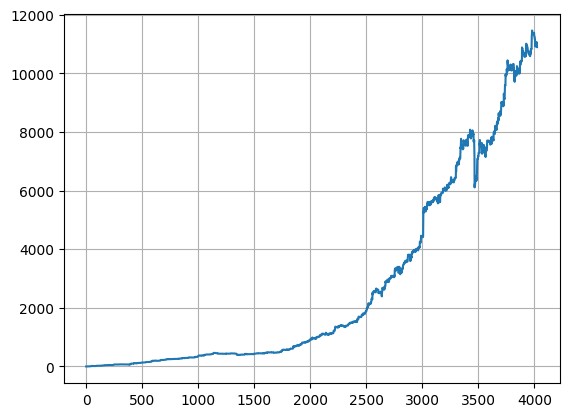

In [23]:
tot = results['total'].diff().cumsum()
t= np.linspace(0,len(tot),len(tot))
plt.plot(t, tot)
plt.grid()

In [24]:
results.iloc[3450:3480,:]

,cash,holdings,total
2024-08-02 12:00:00,8019.544299,0.000000,8019.544299
2024-08-02 16:00:00,8019.544299,0.000000,8019.544299
2024-08-02 20:00:00,8019.544299,0.000000,8019.544299
2024-08-03 00:00:00,8019.544299,0.000000,8019.544299
2024-08-03 04:00:00,0.000000,8010.321823,8010.321823
2024-08-03 08:00:00,0.000000,8045.254458,8045.254458
2024-08-03 12:00:00,0.000000,7900.149668,7900.149668
2024-08-03 16:00:00,0.000000,7768.480507,7768.480507
2024-08-03 20:00:00,0.000000,7795.351764,7795.351764
2024-08-04 00:00:00,0.000000,7827.597273,7827.597273


In [25]:
close = df_all['close']
close.iloc[3450:3480]

2024-08-02 12:00:00    3036
2024-08-02 16:00:00    3008
2024-08-02 20:00:00    2982
2024-08-03 00:00:00    2975
2024-08-03 04:00:00    2981
2024-08-03 08:00:00    2994
2024-08-03 12:00:00    2940
2024-08-03 16:00:00    2891
2024-08-03 20:00:00    2901
2024-08-04 00:00:00    2913
2024-08-04 04:00:00    2890
2024-08-04 08:00:00    2911
2024-08-04 12:00:00    2823
2024-08-04 16:00:00    2755
2024-08-04 20:00:00    2687
2024-08-05 00:00:00    2311
2024-08-05 04:00:00    2356
2024-08-05 08:00:00    2288
2024-08-05 12:00:00    2450
2024-08-05 16:00:00    2403
2024-08-05 20:00:00    2417
2024-08-06 00:00:00    2490
2024-08-06 04:00:00    2522
2024-08-06 08:00:00    2457
2024-08-06 12:00:00    2525
2024-08-06 16:00:00    2491
2024-08-06 20:00:00    2460
2024-08-07 00:00:00    2505
2024-08-07 04:00:00    2509
2024-08-07 08:00:00    2472
Freq: 4h, Name: close, dtype: int64